In [2]:
#LIBRERIA
import numpy as np
import glob
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import scipy.integrate as spi


In [14]:
#AREA EFFICACE

# Area efficace per -1<cos(theta)<0
data_aeff = np.genfromtxt('Aeff/aeffsud.txt', skip_header=1, delimiter=None)
En_log = data_aeff[:,0]
En = pow(10, data_aeff[:, 0])  
Aeff = data_aeff[:, 3] 

# Area efficace per 0<cos(theta)<1
data_aeff_2 = np.genfromtxt('Aeff/aeffnord.txt', skip_header=1, delimiter=None)
En_log_2 = data_aeff_2[:,0]
En_2 = pow(10, data_aeff_2[:, 0])  
Aeff_2 = data_aeff_2[:, 3] 

# Carica l'area effettiva dai dati esterni
'''data_aeff = np.genfromtxt('Aeff/effective_area_sn2023ixf.txt', skip_header=1, delimiter=None)
En_log = data_aeff[:,0]
En = pow(10, data_aeff[:, 0])  
Aeff = data_aeff[:, 3]''' 


'''data_aeff = np.genfromtxt('Aeff/aeff_ARCA230_flavor_numu_selection_track.txt', skip_header=1, delimiter=',')
En_log = data_aeff[:,0]
En = pow(10, data_aeff[:, 0])  
Aeff = data_aeff[:, 1] 
Aeff_sum = sum(Aeff)'''

#seconda declinazione -54
data_aeff_neg = np.genfromtxt('Aeff/effective_area_negdec.txt', skip_header=1, delimiter=None)
En_log_neg = data_aeff_neg[:,0]
En_neg = pow(10, data_aeff_neg[:, 0])  
Aeff_neg = data_aeff_neg[:, 3] 

#seconda declinazione -54 cut 095
data_aeff_neg095 = np.genfromtxt('Aeff/effective_area_negdec095.txt', skip_header=1, delimiter=None)
En_log_neg095 = data_aeff_neg095[:,0]
En_neg095 = pow(10, data_aeff_neg095[:, 0])  
Aeff_neg095 = data_aeff_neg095[:, 3] 


#declinazione 75 cut 095
data_aeff095 = np.genfromtxt('Aeff/effective_area_dec095.txt', skip_header=1, delimiter=None)
En_log095 = data_aeff095[:,0]
En095 = pow(10, data_aeff095[:, 0])  
Aeff095 = data_aeff095[:, 3] 

#declinazione 75 cut 095
data_aeff050 = np.genfromtxt('Aeff/effective_area_050.txt', skip_header=1, delimiter=None)
En_log050 = data_aeff050[:,0]
En050 = pow(10, data_aeff050[:, 0])  
Aeff050 = data_aeff050[:, 3] 




In [15]:

# Funzione di interpolazione per l'area efficace
interpolation_function = interp1d(En, Aeff, kind='linear', fill_value="extrapolate")
En_new = np.linspace(En.min(), En.max(), 500) 
Aeff_new = interpolation_function(En_new) 

interpolation_function_2 = interp1d(En_2, Aeff_2, kind='linear', fill_value="extrapolate")
En_new_2 = np.linspace(En_2.min(), En_2.max(), 500) 
Aeff_new_2 = interpolation_function(En_new_2)  


def integranda(e):
                    
    aeff = interpolation_function(e)  # Assicurati che questa funzione sia definita
    return  aeff
                
Aeff_tot, error= spi.quad(integranda, En_new.min(), En_new.max(), limit=2000)

print(f'{Aeff_tot:2e} {error:2e}')


8.484049e+09 3.101582e+03


C:\Users\Asus\AppData\Local\Temp\ipykernel_19876\1076081703.py:16: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  Aeff_tot, error= spi.quad(integranda, En_new.min(), En_new.max(), limit=2000)


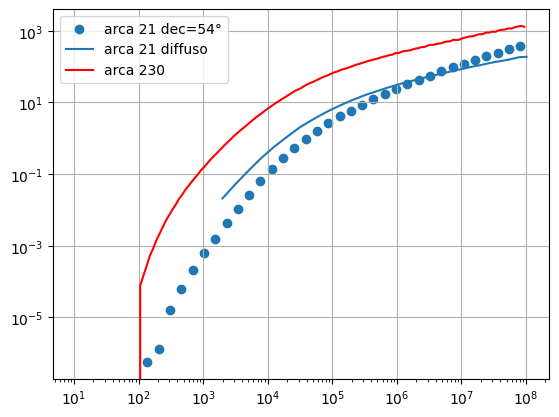

In [73]:
plt.scatter(En, Aeff, label='arca 21 dec=54°')
plt.yscale('log')
#plt.plot(En_new, Aeff_new)

aeff_mer = np.genfromtxt('Aeff/effectiveaream2.dat', delimiter = ',')
aeff_230 = np.genfromtxt('Aeff/aeff_ARCA230_flavor_numu_selection_track.txt', skip_header=1, delimiter=',')

a230 = aeff_230[:, 1]
e230 = aeff_230[:,0]
e230 = pow(10, aeff_230[:,0])

a = aeff_mer[:,1]
e = aeff_mer[:,0]
plt.plot(e, a, label = 'arca 21 diffuso')
plt.plot(e230, a230, c='red', label ='arca 230')
plt.legend()
plt.grid()
plt.xscale('log')

In [12]:
import glob
import numpy as np
import scipy.integrate as spi
from scipy.interpolate import interp1d

# Ottenere la lista di tutti i file .dat nella cartella SN_IIn
file_list = glob.glob('SN_IIn/SNIIn_20_block_*.dat')

# Vettore lightcurve e tempo per IIP S=2.0
time_all_P = []
flux_all_P = []
Num_event = 0.0
Num_tot = []
block_number = []
n_ev = []

block_ranges = [(1, 51)]

for idx, (start_block, end_block) in enumerate(block_ranges, start=1):
    for file_name in file_list:
        # Estrai il numero di blocco dal nome del file
        block_number = int(file_name.split('SNIIn_20_block_')[-1].split('.')[0])
        
        # Controlla se il blocco rientra nel range corrente
        if start_block <= block_number <= end_block:
            # Calcola S_IIn basato sul numero di blocco
            S_IIn_start = 1e5 * pow(10., 0.1 * (block_number - 1))
            S_IIn_stop = 1e5 * pow(10., 0.1 * (block_number))

            delta_t = S_IIn_stop - S_IIn_start
            
            if S_IIn_start > 1e8:
                print(f"Blocco {block_number} ignorato: S_n_start = {S_IIn_start} > 10^8") 
                continue

            # Carica i dati dal file .dat
            new_data = np.loadtxt(file_name)
            
            if new_data[-1, -1] == 1:
                Ev_all = new_data[:, 0]
                Ev = Ev_all[Ev_all > 3e8]
                dN_dEv = new_data[:, 7][Ev_all > 3e8]
                dN_dEv = dN_dEv*(1 / 3)  
                
                lunghezza_Ev = len(Ev)
                time = np.linspace(S_IIn_start, 1e8, lunghezza_Ev)

                interpolation_flux = interp1d(Ev, dN_dEv, kind='cubic', fill_value="extrapolate")
                E_new = np.linspace(Ev.min(), Ev.max(), 500)
                flux_new = interpolation_flux(E_new)

                def integranda(e):
                    flux = interpolation_flux(e)/1e9
                    aeff = interpolation_function(e)  # Assicurati che questa funzione sia definita
                    return flux * aeff
                
                integrale_energia, _ = spi.quad(integranda, En_new.min(), En_new.max(), limit=200)  # Integrale su E con area effettiva

                N_k = integrale_energia * delta_t  # Ponderazione per l'istante temporale t_start_k
                #N_k = np.sum(dN_dEv)
                # Aggiorna il numero totale di eventi attesi
                Num_event += N_k
                Num_tot.append(N_k)
                
                time_all_P.append(block_number) 

#d = 3.086e23 #distanza sorgente 
#geom_con = 1 / (d ** 2)
 
d_min = 10 * 3.086e16  # 10 pc in metri
d_max = 10 * 3.086e22  # 10 Mpc in metri
d_values = np.logspace(np.log10(d_min), np.log10(d_max), 100)  

for d in d_values:
    geom_con = 1 / (4*np.pi*d ** 2)
    expected_events =  Num_event * geom_con
    n_ev.append(expected_events)
    #print(f"Numero totale di eventi attesi: {Num_event * geom_con :.2e}")




C:\Users\Asus\AppData\Local\Temp\ipykernel_19876\1203519981.py:57: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integrale_energia, _ = spi.quad(integranda, En_new.min(), En_new.max(), limit=200)  # Integrale su E con area effettiva


In [16]:
import glob
import numpy as np
import scipy.integrate as spi
from scipy.interpolate import interp1d

# Ottenere la lista di tutti i file .dat nella cartella SN_IIn
file_list = glob.glob('SN_IIn/SNIIn_20_block_*.dat')

# Vettore lightcurve e tempo per IIP S=2.0
time_all_P = []
flux_all_P = []
Num_event = 0.0
Num_tot_2 = []
block_number = []
n_ev_2 = []

block_ranges = [(1, 51)]

for idx, (start_block, end_block) in enumerate(block_ranges, start=1):
    for file_name in file_list:
        # Estrai il numero di blocco dal nome del file
        block_number = int(file_name.split('SNIIn_20_block_')[-1].split('.')[0])
        
        # Controlla se il blocco rientra nel range corrente
        if start_block <= block_number <= end_block:
            # Calcola S_IIn basato sul numero di blocco
            S_IIn_start = 1e5 * pow(10., 0.1 * (block_number - 1))
            S_IIn_stop = 1e5 * pow(10., 0.1 * (block_number))

            delta_t = S_IIn_stop - S_IIn_start
            
            if S_IIn_start > 1e8:
                print(f"Blocco {block_number} ignorato: S_n_start = {S_IIn_start} > 10^8") 
                continue

            # Carica i dati dal file .dat
            new_data = np.loadtxt(file_name)
            
            if new_data[-1, -1] == 1:
                Ev_all = new_data[:, 0]
                Ev = Ev_all[Ev_all > 3e8]
                dN_dEv = new_data[:, 7][Ev_all > 3e8]
                dN_dEv = dN_dEv*(1 / 3)  
                
                lunghezza_Ev = len(Ev)
                time = np.linspace(S_IIn_start, 1e8, lunghezza_Ev)

                interpolation_flux = interp1d(Ev, dN_dEv, kind='cubic', fill_value="extrapolate")
                E_new = np.linspace(Ev.min(), Ev.max(), 500)
                flux_new = interpolation_flux(E_new)

                def integranda(e):
                    flux = interpolation_flux(e)/1e9
                    aeff = interpolation_function_2(e)  # Assicurati che questa funzione sia definita
                    return flux * aeff
                
                integrale_energia, _ = spi.quad(integranda, En_new.min(), En_new.max(), limit=200)  # Integrale su E con area effettiva

                N_k = integrale_energia * delta_t  # Ponderazione per l'istante temporale t_start_k
                #N_k = np.sum(dN_dEv)
                # Aggiorna il numero totale di eventi attesi
                Num_event += N_k
                Num_tot_2.append(N_k)
                
                time_all_P.append(block_number) 

#d = 3.086e23 #distanza sorgente 
#geom_con = 1 / (d ** 2)
 
d_min = 10 * 3.086e16  # 10 pc in metri
d_max = 10 * 3.086e22  # 10 Mpc in metri
d_values = np.logspace(np.log10(d_min), np.log10(d_max), 100)  

for d in d_values:
    geom_con = 1 / (4*np.pi*d ** 2)
    expected_events =  Num_event * geom_con
    n_ev_2.append(expected_events)
    #print(f"Numero totale di eventi attesi: {Num_event * geom_con :.2e}")




C:\Users\Asus\AppData\Local\Temp\ipykernel_19876\526944552.py:57: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integrale_energia, _ = spi.quad(integranda, En_new.min(), En_new.max(), limit=200)  # Integrale su E con area effettiva


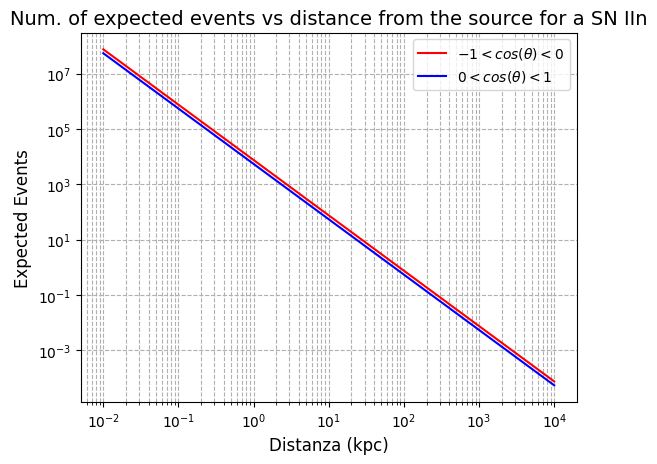

In [20]:
d_values_pc = d_values / 3.086e19
plt.plot(d_values_pc, n_ev, label=r'$-1<cos(\theta)<0$', color='red')
plt.plot(d_values_pc, n_ev_2, label=r'$0<cos(\theta)<1$', color='blue')
plt.xscale('log')  # Scala logaritmica per l'asse delle x (distanza)
plt.yscale('log')  # Scala logaritmica per l'asse delle y (numero di eventi)
plt.xlabel('Distanza (kpc)', fontsize=12)
plt.ylabel('Expected Events', fontsize=12)
plt.title('Num. of expected events vs distance from the source for a SN IIn', fontsize=14)
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

SN2023ixf analysis


In [62]:
import glob
import numpy as np
import scipy.integrate as spi
from scipy.interpolate import interp1d

# Ottenere la lista di tutti i file .dat nella cartella SN_IIn
file_list = glob.glob('SN2023ixf/SN2023ixf_block_*.dat')

# Vettore lightcurve e tempo per IIP S=2.0
N_tot = 0.0
Num_event_P = 0.0
block_number = []
t_tot = 0.0
block_ranges = [(1, 51)]
time = []

#S_IIP_max = 2.484864e7 #ARCA 21 life time
S_IIP_max = 1.1051e7 #Tempo sovrapposizione 2023ixf e ARCA21
stop_processing = False 

for idx, (start_block, end_block) in enumerate(block_ranges, start=1):
    for file_name in file_list:
        # Estrai il numero di blocco dal nome del file
        block_number = int(file_name.split('SN2023ixf_block_')[-1].split('.')[0])
        
        # Controlla se il blocco rientra nel range corrente
        if start_block <= block_number <= end_block:
            # Calcola S_IIP basato sul numero di blocco
            S_IIP_start = 1e3 * pow(10., 0.1 * (block_number - 1))
            S_IIP_stop = 1e3 * pow(10., 0.1 * (block_number))


            if S_IIP_start > S_IIP_max:
                stop_processing = True
                break

            delta_t = S_IIP_stop - S_IIP_start
           
            #print(delta_t)
            
            # Carica i dati dal file .dat
            new_data = np.loadtxt(file_name)
            
            if new_data[-1, -1] == 1:
                Ev_all = new_data[:, 0]
                Ev = Ev_all[Ev_all > 3e8]
                
                dN_dEv = new_data[:, 7][Ev_all > 3e8]
                dN_dEv = dN_dEv * 1/3
                #total_flux =  sum(dN_dEv)

            
                

                interpolation_flux = interp1d(Ev, dN_dEv, kind='linear', fill_value="extrapolate")
                E_new_log = np.logspace(np.log10(Ev.min()), np.log10(Ev.max()), 1000)

                E_new = np.linspace(Ev.min(), Ev.max(), 100)
                flux_new = interpolation_flux(E_new_log)

                def integranda(e):
                    flux = interpolation_flux(e)/1e9
                    
                    aeff = interpolation_function(e)
                     
                    return  aeff * flux
                
                integrale_energia, _ = spi.quad(integranda, En_new.min(), En_new.max(), limit=2000)  # Integrale su E con area effettiva

                N_k = integrale_energia*delta_t # Ponderazione per l'istante temporale t_start_k
                N_k_t = integrale_energia#*delta_t
                t_tot += delta_t
                # Aggiorna il numero totale di eventi attesi
                Num_event_P += N_k
               
                N_tot += N_k_t
                
print(f"{t_tot:.2e}")     

          
#Num_event_P = Num_event_P * 2.484864e7 #ARCA LIFE TIME
print(f"{Num_event_P:.2e}") 
d = 1.975e23 #6.4 Mpc distanza SN2023ixf
geom_con = 1 / (4*np.pi*d ** 2)
print(f"{N_tot:.2e}")

print(f"Numero totale di eventi attesi: {Num_event_P*geom_con:.2e}")


C:\Users\Asus\AppData\Local\Temp\ipykernel_17148\4061364866.py:68: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integrale_energia, _ = spi.quad(integranda, En_new.min(), En_new.max(), limit=2000)  # Integrale su E con area effettiva


1.25e+07
5.16e+40
1.07e+36
Numero totale di eventi attesi: 1.05e-07


SN2021qqu


In [3]:
import glob
import numpy as np
import scipy.integrate as spi
from scipy.interpolate import interp1d




# Ottenere la lista di tutti i file .dat nella cartella SN_IIn
file_list = glob.glob('SN_IIP/SNIIP_20_block_*.dat')

# Vettore lightcurve e tempo per IIP S=2.0
N_tot = 0.0
Num_event_P = 0.0
block_number = []
t_tot = 0.0
block_ranges = [(1, 51)]
time = []

#S_IIP_max = 2.484864e7 #ARCA 21 life time
S_IIP_min = 3.68e7 #Quando ARCA21 è partito erano passati questi secondi dall'esplosione
start_counting = False 

for idx, (start_block, end_block) in enumerate(block_ranges, start=1):
    for file_name in file_list:
        
        #carica l'area efficace e interpola
        data_aeff = np.genfromtxt('Aeff/sn2021qqu.txt', skip_header=1, delimiter=None)
        En_log = data_aeff[:,0]
        En = pow(10, data_aeff[:, 0])  
        Aeff = data_aeff[:, 3] 

        interpolation_function = interp1d(En, Aeff, kind='linear', fill_value="extrapolate")
        En_new = np.linspace(En.min(), En.max(), 500) 
        Aeff_new = interpolation_function(En_new) 

        # Estrai il numero di blocco dal nome del file
        block_number = int(file_name.split('SNIIP_20_block_')[-1].split('.')[0])
        
        
        S_IIP_start = 1e3 * pow(10., 0.1 * (block_number - 1))
        S_IIP_stop = 1e3 * pow(10., 0.1 * (block_number))


        if S_IIP_start >= S_IIP_min:
            start_counting = True
        
        # Ignora i blocchi precedenti a S_IIP_min
        if not start_counting:
                continue

        delta_t = S_IIP_stop - S_IIP_start
           
            #print(delta_t)
            
            # Carica i dati dal file .dat
        new_data = np.loadtxt(file_name)
            
        if new_data[-1, -1] == 1:
                Ev_all = new_data[:, 0]
                Ev = Ev_all[Ev_all > 3e8]
                
                dN_dEv = new_data[:, 7][Ev_all > 3e8]
                dN_dEv = dN_dEv * 1/3
                #total_flux =  sum(dN_dEv)

            
                

                interpolation_flux = interp1d(Ev, dN_dEv, kind='linear', fill_value="extrapolate")
                E_new_log = np.logspace(np.log10(Ev.min()), np.log10(Ev.max()), 1000)

                E_new = np.linspace(Ev.min(), Ev.max(), 100)
                flux_new = interpolation_flux(E_new_log)

                def integranda(e):
                    flux = interpolation_flux(e)/1e9
                    
                    aeff = interpolation_function(e)
                     
                    return  aeff * flux
                
                integrale_energia, _ = spi.quad(integranda, En_new.min(), En_new.max(), limit=2000)  # Integrale su E con area effettiva

                N_k = integrale_energia*delta_t # Ponderazione per l'istante temporale t_start_k
                N_k_t = integrale_energia#*delta_t
                t_tot += delta_t
                # Aggiorna il numero totale di eventi attesi
                Num_event_P += N_k
               
                N_tot += N_k_t
                
print(f"{t_tot:.2e}")     

          
#Num_event_P = Num_event_P * 2.484864e7 #ARCA LIFE TIME
print(f"{Num_event_P:.2e}") 
d = 2.5e23 #8.1 Mpc distanza SN2021qqu
geom_con = 1 / (4*np.pi*d ** 2)
print(f"{N_tot:.2e}")

print(f"Numero totale di eventi attesi: {Num_event_P*geom_con:.2e}")


C:\Users\Asus\AppData\Local\Temp\ipykernel_14444\3633580316.py:83: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integrale_energia, _ = spi.quad(integranda, En_new.min(), En_new.max(), limit=2000)  # Integrale su E con area effettiva


8.61e+07
7.58e+36
4.93e+29
Numero totale di eventi attesi: 9.65e-12
